# Tox21 Full Benchmark (3 Seeds)

This notebook benchmarks classical, uni-modal, bi-modal, tri-modal, and tri-modal fusion models on Tox21 in true multi-label setup with three random seeds.

Compared model families include RF (RDKit), task-wise ChebNet, SEG, TAME, and TAME-Fusion, each with vanilla and stage-1-pretrained variants where applicable.

## Setup
- Dataset: Tox21 (12-task multi-label classification, DeepChem MolNet)
- Split: DeepChem random split (predefined train/valid/test)
- Seeds: `[11, 22, 33]`
- Metric report: Macro ROC-AUC, Macro Accuracy, Macro F1

In [1]:
import sys
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import deepchem as dc

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.cheb_predictor import ChebPredictor, ChebPredictorConfig
from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig
from models.tame_fusion_predictor import TAMEFusionPredictor, TAMEFusionPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Workspace root: {workspace_root}')
print(f'Device: {device}')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace root: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
def find_best_thresholds_multilabel(y_true, y_pred_proba, observed_mask):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred_proba = np.asarray(y_pred_proba, dtype=np.float32)
    observed_mask = np.asarray(observed_mask, dtype=bool)

    if y_true.ndim != 2 or y_pred_proba.ndim != 2:
        raise ValueError('y_true and y_pred_proba must be 2D arrays')
    if y_true.shape != y_pred_proba.shape or y_true.shape != observed_mask.shape:
        raise ValueError('Shape mismatch among y_true, y_pred_proba, observed_mask')

    n_tasks = y_true.shape[1]
    thresholds = np.full((n_tasks,), 0.5, dtype=np.float32)

    for t in range(n_tasks):
        mask_t = observed_mask[:, t] & np.isfinite(y_pred_proba[:, t]) & np.isfinite(y_true[:, t])
        if int(mask_t.sum()) == 0:
            continue

        yt = y_true[mask_t, t]
        yp = np.clip(y_pred_proba[mask_t, t], 0.0, 1.0)

        best_thr = 0.5
        best_f1 = -1.0
        best_acc = -1.0
        for thr in np.linspace(0.05, 0.95, 181):
            yhat = (yp >= thr).astype(np.float32)
            tp = float(np.sum((yhat == 1) & (yt == 1)))
            tn = float(np.sum((yhat == 0) & (yt == 0)))
            fp = float(np.sum((yhat == 1) & (yt == 0)))
            fn = float(np.sum((yhat == 0) & (yt == 1)))
            acc = float((tp + tn) / max(tp + tn + fp + fn, 1.0))
            precision = float(tp / max(tp + fp, 1.0))
            recall = float(tp / max(tp + fn, 1.0))
            f1 = float(2.0 * precision * recall / max(precision + recall, 1e-12))
            if (f1 > best_f1) or (np.isclose(f1, best_f1) and acc > best_acc):
                best_f1 = f1
                best_acc = acc
                best_thr = float(thr)

        thresholds[t] = best_thr

    return thresholds

def multilabel_metrics(y_true, y_pred_proba, observed_mask, thresholds=None):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred_proba = np.asarray(y_pred_proba, dtype=np.float32)
    observed_mask = np.asarray(observed_mask, dtype=bool)

    if y_true.ndim != 2 or y_pred_proba.ndim != 2:
        raise ValueError('y_true and y_pred_proba must be 2D arrays')
    if y_true.shape != y_pred_proba.shape or y_true.shape != observed_mask.shape:
        raise ValueError('Shape mismatch among y_true, y_pred_proba, observed_mask')

    n_tasks = y_true.shape[1]
    if thresholds is None:
        thresholds = np.full((n_tasks,), 0.5, dtype=np.float32)
    thresholds = np.asarray(thresholds, dtype=np.float32).reshape(-1)
    if thresholds.shape[0] != n_tasks:
        raise ValueError('thresholds length must match number of tasks')

    aucs, accs, f1s = [], [], []
    for t in range(n_tasks):
        mask_t = observed_mask[:, t] & np.isfinite(y_pred_proba[:, t]) & np.isfinite(y_true[:, t])
        if int(mask_t.sum()) == 0:
            continue

        yt = y_true[mask_t, t]
        yp = np.clip(y_pred_proba[mask_t, t], 0.0, 1.0)
        yhat = (yp >= float(thresholds[t])).astype(np.float32)

        if np.unique(yt).size > 1:
            aucs.append(float(roc_auc_score(yt, yp)))
        else:
            aucs.append(np.nan)
        accs.append(float(accuracy_score(yt, yhat)))
        f1s.append(float(f1_score(yt, yhat, zero_division=0)))

    return {
        'macro_roc_auc': float(np.nanmean(aucs)) if len(aucs) else np.nan,
        'macro_accuracy': float(np.nanmean(accs)) if len(accs) else np.nan,
        'macro_f1': float(np.nanmean(f1s)) if len(f1s) else np.nan,
        'n_tasks_eval': int(len(accs)),
        'threshold_mean': float(np.nanmean(thresholds)) if len(thresholds) else np.nan,
    }

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue
        all_desc = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_desc.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))
    return np.vstack(rows).astype(np.float32), desc_names

def impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(train_X, axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)

@contextmanager
def patch_build_model_with_encoder_init(predictor, encoder_state, strict=True):
    original_build_model = predictor._build_model

    def _patched_build_model(*args, **kwargs):
        result = original_build_model(*args, **kwargs)
        if getattr(predictor, '_encoder', None) is None:
            raise RuntimeError('Predictor encoder is not initialized after _build_model()')
        predictor._encoder.load_state_dict(encoder_state, strict=strict)
        return result

    predictor._build_model = _patched_build_model
    try:
        yield
    finally:
        predictor._build_model = original_build_model

In [3]:
# Benchmark seeds
SEEDS = [11, 22, 33]

tasks, datasets, _ = dc.molnet.load_tox21(featurizer='ECFP', splitter='random')
train_dc, valid_dc, test_dc = datasets

NUM_TASKS = int(len(tasks))

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

def _prepare_multilabel(ds):
    y = np.asarray(ds.y, dtype=np.float32)
    w = np.asarray(ds.w, dtype=np.float32)
    obs = (w > 0) & np.isfinite(y)
    y_masked = np.where(obs, np.clip(y, 0.0, 1.0), np.nan).astype(np.float32)
    return y_masked, obs

train_y_mat, train_mask = _prepare_multilabel(train_dc)
valid_y_mat, valid_mask = _prepare_multilabel(valid_dc)
test_y_mat, test_mask = _prepare_multilabel(test_dc)

emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'toxicity_fast_text_embeddings_compact.npz'
if not npz_path.exists():
    raise FileNotFoundError(f'Embedding cache not found: {npz_path}')

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = torch.from_numpy(seg_cache.get_batch(all_smiles)).float()
n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = all_emb[:n_train]
valid_emb = all_emb[n_train:n_train + n_valid]
test_emb = all_emb[n_train + n_valid:]

d_train, desc_names = rdkit_descriptor_matrix(train_smiles)
d_valid, _ = rdkit_descriptor_matrix(valid_smiles)
d_test, _ = rdkit_descriptor_matrix(test_smiles)
d_train, d_valid, d_test = impute_with_train_median(d_train, d_valid, d_test)

print(f'Tox21 tasks: {NUM_TASKS}')
print(f'Sizes -> train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}')
print(f'Observed labels -> train={int(train_mask.sum())}, val={int(valid_mask.sum())}, test={int(test_mask.sum())}')
print(f'Text embedding dim: {all_emb.shape[1]} | Descriptor dim: {d_train.shape[1]}')

Loading embeddings from toxicity_fast_text_embeddings_compact.npz...
  Loaded 7823 entries, dim=3072
  Memory mode: mapped


C:\Users\robsc\AppData\Local\Temp\ipykernel_30788\2633255589.py:102: RuntimeWarning: overflow encountered in cast
  rows.append(np.asarray(row, dtype=np.float32))


Tox21 tasks: 12
Sizes -> train=6258, val=782, test=783
Observed labels -> train=62276, val=7705, test=7883
Text embedding dim: 3072 | Descriptor dim: 217


In [4]:
CHEB_FIT_KWARGS = {
    'num_epochs': 140,
    'batch_size': 64,
    'learning_rate': 5e-4,
    'weight_decay': 1e-2,
    'patience': 20,
}

SEG_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'text_proj_init': 'xavier',
    'text_proj_init_gain': 0.1,
    'freeze_text_proj': False,
    'dropout': 0.3,
    'fusion_dropout': 0.3,
    'head_dropout': 0.5,
    'head_type': 'mlp',
    'head_hidden_dim': 32,
    'learning_rate': 5e-3,
    'weight_decay': 1e-1,
    'batch_size': 64,
    'num_epochs': 200,
    'patience': 30,
    'scheduler': 'cosine',
    'scheduler_patience': 5,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': None,
}

TAME_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion_hidden_dim': 64,
    'projection_dropout': 0.30,
    'router_dropout': 0.35,
    'head_hidden_dim': 64,
    'head_dropout': 0.30,
    'learning_rate': 5e-4,
    'weight_decay': 7e-2,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.25,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 120,
    'patience': 15,
}

TAME_FUSION_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'fusion_dropout': 0.30,
    'moe_hidden_dim': 64,
    'projection_dropout': 0.30,
    'router_dropout': 0.35,
    'head_hidden_dim': 64,
    'head_dropout': 0.30,
    'learning_rate': 5e-4,
    'weight_decay': 7e-2,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.25,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 120,
    'patience': 15,
}

BACKBONE_ARCH = {
    'hidden_channels': SEG_FIT_KWARGS['hidden_channels'],
    'num_layers': SEG_FIT_KWARGS['num_layers'],
    'K': SEG_FIT_KWARGS['K'],
    'pool': SEG_FIT_KWARGS['pool'],
}

def make_cheb_config():
    return ChebPredictorConfig(
        task='classification',
        hidden_channels=BACKBONE_ARCH['hidden_channels'],
        K=BACKBONE_ARCH['K'],
        num_layers=BACKBONE_ARCH['num_layers'],
        dropout=0.2,
        pool=BACKBONE_ARCH['pool'],
        set2set_processing_steps=6,
        add_hydrogens=False,
        head_hidden_dim=64,
        head_dropout=0.2,
    )

def make_seg_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='classification',
        num_tasks=NUM_TASKS,
        hidden_channels=SEG_FIT_KWARGS['hidden_channels'],
        K=SEG_FIT_KWARGS['K'],
        num_layers=SEG_FIT_KWARGS['num_layers'],
        dropout=SEG_FIT_KWARGS['dropout'],
        pool=SEG_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_FIT_KWARGS['fusion'],
        fusion_dim=SEG_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_FIT_KWARGS['head_dropout'],
        add_hydrogens=False,
    )

def make_tame_config(text_embedding_dim):
    return TAMEPredictorConfig(
        task='classification',
        num_tasks=NUM_TASKS,
        hidden_channels=TAME_FIT_KWARGS['hidden_channels'],
        K=TAME_FIT_KWARGS['K'],
        num_layers=TAME_FIT_KWARGS['num_layers'],
        pool=TAME_FIT_KWARGS['pool'],
        text_embedding_dim=int(text_embedding_dim),
        fusion_hidden_dim=TAME_FIT_KWARGS['fusion_hidden_dim'],
        projection_dropout=TAME_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def make_tame_fusion_config(text_embedding_dim):
    return TAMEFusionPredictorConfig(
        task='classification',
        num_tasks=NUM_TASKS,
        hidden_channels=TAME_FUSION_FIT_KWARGS['hidden_channels'],
        K=TAME_FUSION_FIT_KWARGS['K'],
        num_layers=TAME_FUSION_FIT_KWARGS['num_layers'],
        pool=TAME_FUSION_FIT_KWARGS['pool'],
        set2set_processing_steps=TAME_FUSION_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        fusion=TAME_FUSION_FIT_KWARGS['fusion'],
        fusion_dim=TAME_FUSION_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=TAME_FUSION_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=TAME_FUSION_FIT_KWARGS['fusion_dropout'],
        moe_hidden_dim=TAME_FUSION_FIT_KWARGS['moe_hidden_dim'],
        projection_dropout=TAME_FUSION_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FUSION_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FUSION_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FUSION_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FUSION_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FUSION_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FUSION_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FUSION_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FUSION_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def _arch_from_encoder_state(encoder_state):
    layer_ids = sorted({
        int(k.split('.')[1])
        for k in encoder_state.keys()
        if k.startswith('layers.') and k.endswith('.weight')
    })
    if not layer_ids:
        raise RuntimeError('No encoder layer weights found in encoder_state.')

    first_weight_key = f'layers.{layer_ids[0]}.weight'
    first_weight = encoder_state[first_weight_key]
    if first_weight.ndim != 3:
        raise RuntimeError(
            f'Unexpected encoder weight shape for {first_weight_key}: {tuple(first_weight.shape)}'
        )

    return {
        'K': int(first_weight.shape[0]),
        'hidden_channels': int(first_weight.shape[-1]),
        'num_layers': int(max(layer_ids) + 1),
    }

def resolve_pretrain_checkpoint(pretrain_stage, *, hidden_channels, num_layers, K, pool):
    stage_cfg = {
        'stage1_node': {'pattern_prefix': 'cheb_foundation_stage1'},
        'stage2_descriptor': {'pattern_prefix': 'cheb_foundation_2stage'},
    }
    if pretrain_stage not in stage_cfg:
        raise ValueError(f'Unsupported pretrain_stage={pretrain_stage!r}')

    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    pattern_prefix = stage_cfg[pretrain_stage]['pattern_prefix']
    pattern = f"{pattern_prefix}__h{int(hidden_channels)}__L{int(num_layers)}__K{int(K)}__pool-{pool}__*.pt"
    candidates = sorted(
        [p for p in ckpt_dir.glob(pattern) if '__fallback__' not in p.name],
        key=lambda p: p.stat().st_mtime, reverse=True
    )
    if not candidates:
        raise FileNotFoundError(
            f"No checkpoint found for stage={pretrain_stage!r} with required pattern={pattern!r}."
        )
    return candidates[0]

def load_pretrained_encoder_state(ckpt_path, expected_stage, expected_arch):
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if not isinstance(payload, dict):
        raise RuntimeError('Invalid checkpoint payload format.')

    stage = payload.get('pretraining_stage', None)
    if stage != expected_stage:
        raise RuntimeError(
            f"Expected checkpoint with pretraining_stage={expected_stage!r}, got {stage!r}"
        )

    model_state = payload.get('model_state_dict', {})
    enc_state = {k.replace('encoder.', '', 1): v for k, v in model_state.items() if k.startswith('encoder.')}
    if not enc_state:
        raise RuntimeError('Checkpoint does not contain encoder.* weights.')

    arch = _arch_from_encoder_state(enc_state)
    for k in ('hidden_channels', 'K', 'num_layers'):
        if int(arch[k]) != int(expected_arch[k]):
            raise RuntimeError(
                f"Checkpoint architecture mismatch for {Path(ckpt_path).name}: {k}={arch[k]} but expected {expected_arch[k]}"
            )

    print(f'Loaded {expected_stage} encoder state from: {Path(ckpt_path).resolve()}')
    return enc_state

CHEB_ENCODER_ARCH = dict(BACKBONE_ARCH)
SEG_ENCODER_ARCH = {
    'hidden_channels': SEG_FIT_KWARGS['hidden_channels'],
    'num_layers': SEG_FIT_KWARGS['num_layers'],
    'K': SEG_FIT_KWARGS['K'],
    'pool': SEG_FIT_KWARGS['pool'],
}
TAME_ENCODER_ARCH = {
    'hidden_channels': TAME_FIT_KWARGS['hidden_channels'],
    'num_layers': TAME_FIT_KWARGS['num_layers'],
    'K': TAME_FIT_KWARGS['K'],
    'pool': TAME_FIT_KWARGS['pool'],
}
TAME_FUSION_ENCODER_ARCH = {
    'hidden_channels': TAME_FUSION_FIT_KWARGS['hidden_channels'],
    'num_layers': TAME_FUSION_FIT_KWARGS['num_layers'],
    'K': TAME_FUSION_FIT_KWARGS['K'],
    'pool': TAME_FUSION_FIT_KWARGS['pool'],
}

stage1_cheb_ckpt = resolve_pretrain_checkpoint('stage1_node', **CHEB_ENCODER_ARCH)
stage1_seg_ckpt = resolve_pretrain_checkpoint('stage1_node', **SEG_ENCODER_ARCH)
stage1_tame_ckpt = resolve_pretrain_checkpoint('stage1_node', **TAME_ENCODER_ARCH)
stage1_tame_fusion_ckpt = resolve_pretrain_checkpoint('stage1_node', **TAME_FUSION_ENCODER_ARCH)

stage1_cheb_encoder_state = load_pretrained_encoder_state(stage1_cheb_ckpt, 'stage1_node', CHEB_ENCODER_ARCH)
stage1_seg_encoder_state = load_pretrained_encoder_state(stage1_seg_ckpt, 'stage1_node', SEG_ENCODER_ARCH)
stage1_tame_encoder_state = load_pretrained_encoder_state(stage1_tame_ckpt, 'stage1_node', TAME_ENCODER_ARCH)
stage1_tame_fusion_encoder_state = load_pretrained_encoder_state(stage1_tame_fusion_ckpt, 'stage1_node', TAME_FUSION_ENCODER_ARCH)

Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt


In [5]:
def _valid_task(mask_col, y_col):
    obs = np.asarray(mask_col, dtype=bool) & np.isfinite(np.asarray(y_col, dtype=np.float32))
    if int(obs.sum()) < 20:
        return False
    return np.unique(np.asarray(y_col, dtype=np.float32)[obs]).size > 1

def _rf_predict_proba_multilabel(rf, X):
    raw = rf.predict_proba(X)
    if not isinstance(raw, list):
        raw = [raw]

    probs = []
    for t, p in enumerate(raw):
        p = np.asarray(p, dtype=np.float32)
        classes_t = np.asarray(rf.classes_[t]) if isinstance(rf.classes_, list) else np.asarray(rf.classes_)
        if p.ndim != 2 or p.shape[0] != X.shape[0]:
            raise RuntimeError(f'Unexpected predict_proba output shape for task {t}: {p.shape}')

        if p.shape[1] == 1:
            only_cls = float(classes_t[0]) if classes_t.size else 0.0
            prob_pos = np.ones((X.shape[0],), dtype=np.float32) if only_cls >= 0.5 else np.zeros((X.shape[0],), dtype=np.float32)
        else:
            pos_idx = np.where(classes_t == 1)[0]
            if pos_idx.size == 0:
                prob_pos = np.zeros((X.shape[0],), dtype=np.float32)
            else:
                prob_pos = p[:, int(pos_idx[0])].astype(np.float32)
        probs.append(prob_pos)

    return np.stack(probs, axis=1).astype(np.float32)

def run_rf(seed):
    complete_train = np.all(train_mask, axis=1) & np.all(np.isfinite(train_y_mat), axis=1)
    n_complete = int(complete_train.sum())
    if n_complete < 100:
        raise RuntimeError(
            f'Not enough fully-observed samples for multilabel RF training: {n_complete}. '
            'Increase data coverage or adjust the training strategy.'
        )

    y_train_complete = train_y_mat[complete_train].astype(np.int64)
    rf = RandomForestClassifier(
        n_estimators=600,
        max_features='sqrt',
        min_samples_leaf=1,
        random_state=int(seed),
        n_jobs=-1,
    )
    rf.fit(d_train[complete_train], y_train_complete)

    valid_pred = _rf_predict_proba_multilabel(rf, d_valid)
    test_pred = _rf_predict_proba_multilabel(rf, d_test)

    thresholds = find_best_thresholds_multilabel(valid_y_mat, valid_pred, valid_mask)
    m = multilabel_metrics(test_y_mat, test_pred, test_mask, thresholds=thresholds)
    m['model'] = 'RF_RDKit_MULTILABEL'
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(NUM_TASKS)
    m['n_complete_train_samples'] = int(n_complete)
    return m

def run_cheb(seed, encoder_init_state=None, label='CHEBNET_TASKWISE_VANILLA'):
    valid_pred = np.full_like(valid_y_mat, np.nan, dtype=np.float32)
    test_pred = np.full_like(test_y_mat, np.nan, dtype=np.float32)
    thresholds = np.full((NUM_TASKS,), 0.5, dtype=np.float32)
    history = {}
    n_trained = 0

    for t in range(NUM_TASKS):
        if not _valid_task(train_mask[:, t], train_y_mat[:, t]):
            continue

        tr_obs = train_mask[:, t] & np.isfinite(train_y_mat[:, t])
        va_obs = valid_mask[:, t] & np.isfinite(valid_y_mat[:, t])
        if int(va_obs.sum()) < 10:
            continue
        if np.unique(valid_y_mat[va_obs, t]).size < 2:
            continue

        tr_smiles = [s for s, k in zip(train_smiles, tr_obs) if k]
        va_smiles = [s for s, k in zip(valid_smiles, va_obs) if k]
        tr_labels = train_y_mat[tr_obs, t].astype(np.float32).tolist()
        va_labels = valid_y_mat[va_obs, t].astype(np.float32).tolist()

        cheb = ChebPredictor(config=make_cheb_config(), device=str(device))
        fit_kwargs = dict(
            smiles_list=tr_smiles, labels=tr_labels,
            val_smiles=va_smiles, val_labels=va_labels,
            num_epochs=CHEB_FIT_KWARGS['num_epochs'],
            batch_size=CHEB_FIT_KWARGS['batch_size'],
            learning_rate=CHEB_FIT_KWARGS['learning_rate'],
            weight_decay=CHEB_FIT_KWARGS['weight_decay'],
            patience=CHEB_FIT_KWARGS['patience'],
            verbose=False, seed=int(seed + t * 53),
        )

        if encoder_init_state is None:
            hist = cheb.fit(**fit_kwargs)
        else:
            with patch_build_model_with_encoder_init(cheb, encoder_init_state, strict=True):
                hist = cheb.fit(**fit_kwargs)

        valid_pred[:, t] = np.asarray(cheb.predict_batch(valid_smiles, batch_size=128), dtype=np.float32).reshape(-1)
        test_pred[:, t] = np.asarray(cheb.predict_batch(test_smiles, batch_size=128), dtype=np.float32).reshape(-1)

        thr_t = find_best_thresholds_multilabel(
            valid_y_mat[:, [t]], valid_pred[:, [t]], valid_mask[:, [t]]
        )[0]
        thresholds[t] = float(thr_t)
        history[int(t)] = hist
        n_trained += 1

    m = multilabel_metrics(test_y_mat, test_pred, test_mask, thresholds=thresholds)
    m['model'] = label
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(n_trained)
    return m, history

def run_seg(seed, encoder_init_state=None, label='SEG_VANILLA'):
    seg = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=train_y_mat.tolist(),
        val_smiles=valid_smiles,
        val_labels=valid_y_mat.tolist(),
        text_embeddings=train_emb,
        val_text_embeddings=valid_emb,
        num_epochs=SEG_FIT_KWARGS['num_epochs'],
        batch_size=SEG_FIT_KWARGS['batch_size'],
        learning_rate=SEG_FIT_KWARGS['learning_rate'],
        weight_decay=SEG_FIT_KWARGS['weight_decay'],
        patience=SEG_FIT_KWARGS['patience'],
        scheduler=SEG_FIT_KWARGS['scheduler'],
        scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
        scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
        min_lr=SEG_FIT_KWARGS['min_lr'],
        grad_clip=SEG_FIT_KWARGS['grad_clip'],
        seed=int(seed),
        verbose=False,
    )

    if encoder_init_state is None:
        hist = seg.fit(**fit_kwargs)
    else:
        with patch_build_model_with_encoder_init(seg, encoder_init_state, strict=True):
            hist = seg.fit(**fit_kwargs)

    valid_proba = np.asarray(seg.predict_batch(valid_smiles, text_embeddings=valid_emb), dtype=np.float32)
    test_proba = np.asarray(seg.predict_batch(test_smiles, text_embeddings=test_emb), dtype=np.float32)
    thresholds = find_best_thresholds_multilabel(valid_y_mat, valid_proba, valid_mask)
    m = multilabel_metrics(test_y_mat, test_proba, test_mask, thresholds=thresholds)
    m['model'] = label
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(NUM_TASKS)
    return m, hist

def run_tame(seed, encoder_init_state=None, label='TAME_VANILLA'):
    tame = TAMEPredictor(config=make_tame_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=train_y_mat.tolist(),
        val_smiles=valid_smiles,
        val_labels=valid_y_mat.tolist(),
        text_embeddings=train_emb.numpy(),
        val_text_embeddings=valid_emb.numpy(),
        descriptor_features=d_train,
        val_descriptor_features=d_valid,
        num_epochs=TAME_FIT_KWARGS['num_epochs'],
        batch_size=TAME_FIT_KWARGS['batch_size'],
        learning_rate=TAME_FIT_KWARGS['learning_rate'],
        weight_decay=TAME_FIT_KWARGS['weight_decay'],
        patience=TAME_FIT_KWARGS['patience'],
        seed=int(seed),
        verbose=False,
    )
    if encoder_init_state is not None:
        fit_kwargs['init_encoder_state'] = encoder_init_state

    hist = tame.fit(**fit_kwargs)

    valid_proba = np.asarray(
        tame.predict_batch(valid_smiles, text_embeddings=valid_emb.numpy(), descriptor_features=d_valid),
        dtype=np.float32,
    )
    test_proba = np.asarray(
        tame.predict_batch(test_smiles, text_embeddings=test_emb.numpy(), descriptor_features=d_test),
        dtype=np.float32,
    )
    thresholds = find_best_thresholds_multilabel(valid_y_mat, valid_proba, valid_mask)
    m = multilabel_metrics(test_y_mat, test_proba, test_mask, thresholds=thresholds)
    m['model'] = label
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(NUM_TASKS)
    return m, hist

def run_tame_fusion(seed, encoder_init_state=None, label='TAME_FUSION_VANILLA'):
    tame_fusion = TAMEFusionPredictor(config=make_tame_fusion_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=train_y_mat.tolist(),
        val_smiles=valid_smiles,
        val_labels=valid_y_mat.tolist(),
        text_embeddings=train_emb.numpy(),
        val_text_embeddings=valid_emb.numpy(),
        descriptor_features=d_train,
        val_descriptor_features=d_valid,
        num_epochs=TAME_FUSION_FIT_KWARGS['num_epochs'],
        batch_size=TAME_FUSION_FIT_KWARGS['batch_size'],
        learning_rate=TAME_FUSION_FIT_KWARGS['learning_rate'],
        weight_decay=TAME_FUSION_FIT_KWARGS['weight_decay'],
        patience=TAME_FUSION_FIT_KWARGS['patience'],
        seed=int(seed),
        verbose=False,
    )
    if encoder_init_state is not None:
        fit_kwargs['init_encoder_state'] = encoder_init_state

    hist = tame_fusion.fit(**fit_kwargs)

    valid_proba = np.asarray(
        tame_fusion.predict_batch(valid_smiles, text_embeddings=valid_emb.numpy(), descriptor_features=d_valid),
        dtype=np.float32,
    )
    test_proba = np.asarray(
        tame_fusion.predict_batch(test_smiles, text_embeddings=test_emb.numpy(), descriptor_features=d_test),
        dtype=np.float32,
    )
    thresholds = find_best_thresholds_multilabel(valid_y_mat, valid_proba, valid_mask)
    m = multilabel_metrics(test_y_mat, test_proba, test_mask, thresholds=thresholds)
    m['model'] = label
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(NUM_TASKS)
    return m, hist

In [6]:
results_dir = workspace_root / 'benchmarking' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
progress_raw_path = results_dir / 'tox21_full_benchmark_3seed_raw_progress.csv'
progress_history_path = results_dir / 'tox21_full_benchmark_3seed_history_progress.pt'

all_rows = []
history_bank = {}

for seed in SEEDS:
    print(f'Running seed {seed} ...')

    rf_row = run_rf(seed)
    all_rows.append(rf_row)

    cheb_v_row, cheb_v_hist = run_cheb(seed, encoder_init_state=None, label='CHEBNET_TASKWISE_VANILLA')
    all_rows.append(cheb_v_row)
    history_bank[(seed, 'CHEBNET_TASKWISE_VANILLA')] = cheb_v_hist

    cheb_p_row, cheb_p_hist = run_cheb(seed, encoder_init_state=stage1_cheb_encoder_state, label='CHEBNET_TASKWISE_PRETRAINED_STAGE1')
    all_rows.append(cheb_p_row)
    history_bank[(seed, 'CHEBNET_TASKWISE_PRETRAINED_STAGE1')] = cheb_p_hist

    seg_v_row, seg_v_hist = run_seg(seed, encoder_init_state=None, label='SEG_VANILLA')
    all_rows.append(seg_v_row)
    history_bank[(seed, 'SEG_VANILLA')] = seg_v_hist

    seg_p_row, seg_p_hist = run_seg(seed, encoder_init_state=stage1_seg_encoder_state, label='SEG_PRETRAINED_STAGE1')
    all_rows.append(seg_p_row)
    history_bank[(seed, 'SEG_PRETRAINED_STAGE1')] = seg_p_hist

    tame_v_row, tame_v_hist = run_tame(seed, encoder_init_state=None, label='TAME_VANILLA')
    all_rows.append(tame_v_row)
    history_bank[(seed, 'TAME_VANILLA')] = tame_v_hist

    tame_p_row, tame_p_hist = run_tame(seed, encoder_init_state=stage1_tame_encoder_state, label='TAME_PRETRAINED_STAGE1')
    all_rows.append(tame_p_row)
    history_bank[(seed, 'TAME_PRETRAINED_STAGE1')] = tame_p_hist

    tf_v_row, tf_v_hist = run_tame_fusion(seed, encoder_init_state=None, label='TAME_FUSION_VANILLA')
    all_rows.append(tf_v_row)
    history_bank[(seed, 'TAME_FUSION_VANILLA')] = tf_v_hist

    tf_p_row, tf_p_hist = run_tame_fusion(seed, encoder_init_state=stage1_tame_fusion_encoder_state, label='TAME_FUSION_PRETRAINED_STAGE1')
    all_rows.append(tf_p_row)
    history_bank[(seed, 'TAME_FUSION_PRETRAINED_STAGE1')] = tf_p_hist

    # Persist after each seed so summary/plot can be reproduced without rerunning training.
    progress_df = pd.DataFrame(all_rows)
    progress_df.to_csv(progress_raw_path, index=False)
    torch.save(history_bank, progress_history_path)
    print(f'  saved progress -> {progress_raw_path.name}, {progress_history_path.name}')

results_df = pd.DataFrame(all_rows)
results_df = results_df[[
    'model', 'seed', 'macro_roc_auc', 'macro_accuracy', 'macro_f1',
    'threshold_mean', 'n_tasks_eval', 'n_tasks_trained'
]]
results_df

Running seed 11 ...
  saved progress -> tox21_full_benchmark_3seed_raw_progress.csv, tox21_full_benchmark_3seed_history_progress.pt
Running seed 22 ...
  saved progress -> tox21_full_benchmark_3seed_raw_progress.csv, tox21_full_benchmark_3seed_history_progress.pt
Running seed 33 ...
  saved progress -> tox21_full_benchmark_3seed_raw_progress.csv, tox21_full_benchmark_3seed_history_progress.pt


,model,seed,macro_roc_auc,macro_accuracy,macro_f1,threshold_mean,n_tasks_eval,n_tasks_trained
0,RF_RDKit_MULTILABEL,11,0.783194,0.882195,0.363573,0.138333,12,12
1,CHEBNET_TASKWISE_VANILLA,11,0.739687,0.836380,0.275616,0.127083,12,12
2,CHEBNET_TASKWISE_PRETRAINED_STAGE1,11,0.775610,0.880751,0.352526,0.166667,12,12
3,SEG_VANILLA,11,0.809461,0.890085,0.410282,0.206250,12,12
4,SEG_PRETRAINED_STAGE1,11,0.810220,0.894390,0.403794,0.234167,12,12
5,TAME_VANILLA,11,0.837853,0.918187,0.464326,0.312500,12,12
6,TAME_PRETRAINED_STAGE1,11,0.844623,0.912078,0.478527,0.325833,12,12
7,TAME_FUSION_VANILLA,11,0.836194,0.918937,0.483085,0.194583,12,12
8,TAME_FUSION_PRETRAINED_STAGE1,11,0.831878,0.915945,0.470615,0.348750,12,12
9,RF_RDKit_MULTILABEL,22,0.786442,0.881586,0.361669,0.135833,12,12


Saved plot: C:\Users\robsc\Nextcloud\Studium\Master Chemie\PC Modul\PC F-Praktikum BASF\PC F-Bericht\images\tox21_full_benchmark_3seed.png


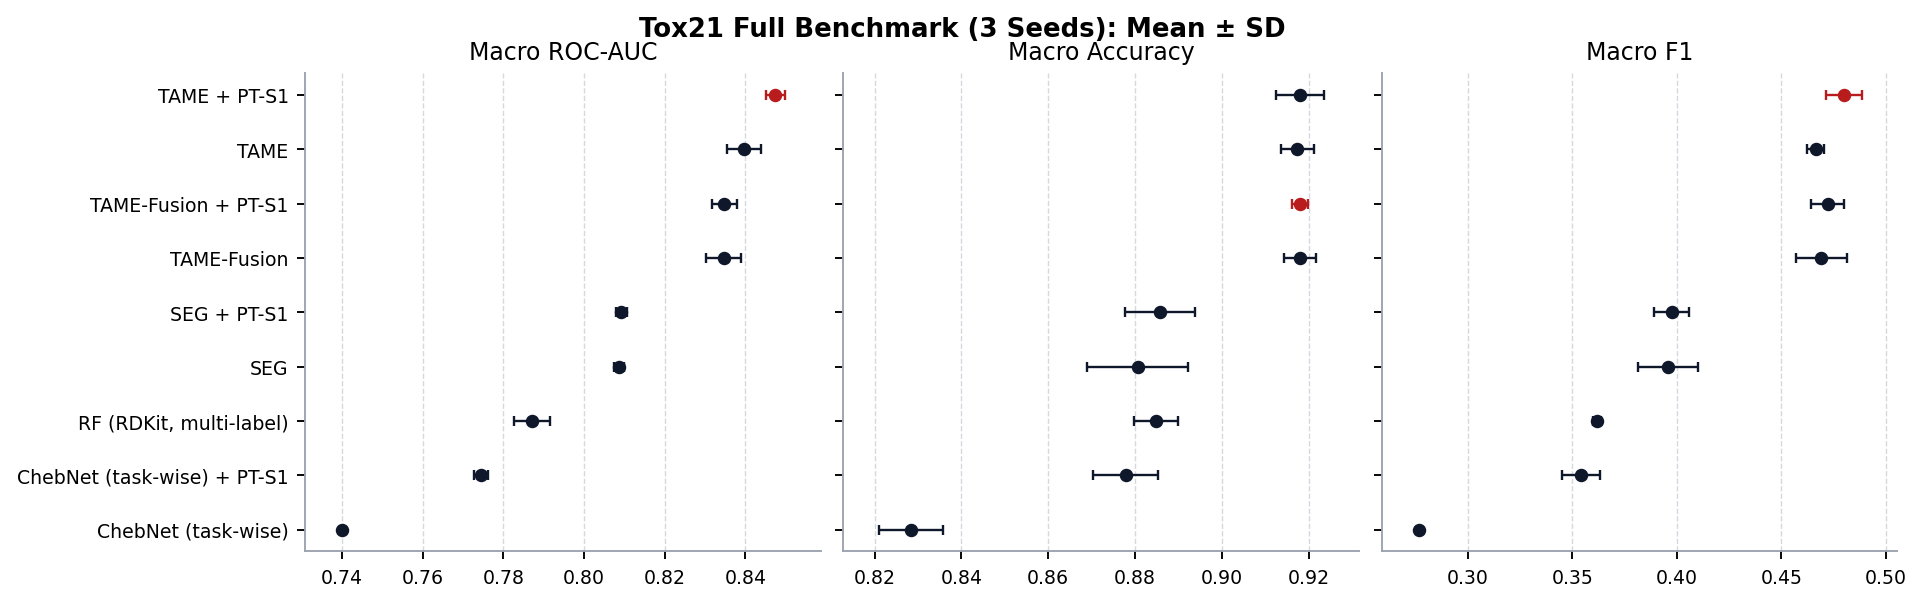

In [7]:
summary_df = results_df.groupby('model', as_index=False).agg(
    macro_roc_auc_mean=('macro_roc_auc', 'mean'),
    macro_roc_auc_std=('macro_roc_auc', 'std'),
    macro_accuracy_mean=('macro_accuracy', 'mean'),
    macro_accuracy_std=('macro_accuracy', 'std'),
    macro_f1_mean=('macro_f1', 'mean'),
    macro_f1_std=('macro_f1', 'std'),
    threshold_mean=('threshold_mean', 'mean'),
    n_tasks_eval_mean=('n_tasks_eval', 'mean'),
    n_runs=('seed', 'nunique'),
)
summary_df = summary_df.sort_values('macro_roc_auc_mean', ascending=False).reset_index(drop=True)
summary_df

label_map = {
    'RF_RDKit_MULTILABEL': 'RF (RDKit, multi-label)',
    'CHEBNET_TASKWISE_VANILLA': 'ChebNet (task-wise)',
    'CHEBNET_TASKWISE_PRETRAINED_STAGE1': 'ChebNet (task-wise) + PT-S1',
    'SEG_VANILLA': 'SEG',
    'SEG_PRETRAINED_STAGE1': 'SEG + PT-S1',
    'TAME_VANILLA': 'TAME',
    'TAME_PRETRAINED_STAGE1': 'TAME + PT-S1',
    'TAME_FUSION_VANILLA': 'TAME-Fusion',
    'TAME_FUSION_PRETRAINED_STAGE1': 'TAME-Fusion + PT-S1',
}
plot_df = summary_df.copy()
plot_df['label'] = plot_df['model'].map(label_map).fillna(plot_df['model'])

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 400,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#111111',
    'axes.linewidth': 0.8,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

y = np.arange(len(plot_df))
y_labels = plot_df['label'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.3), sharey=True, constrained_layout=True)
metrics = [
    ('macro_roc_auc_mean', 'macro_roc_auc_std', 'Macro ROC-AUC'),
    ('macro_accuracy_mean', 'macro_accuracy_std', 'Macro Accuracy'),
    ('macro_f1_mean', 'macro_f1_std', 'Macro F1'),
]

for ax, (m_col, s_col, title) in zip(axes, metrics):
    mu = plot_df[m_col].to_numpy(dtype=np.float32)
    sd = plot_df[s_col].fillna(0.0).to_numpy(dtype=np.float32)
    best_idx = int(np.argmax(mu))

    for i in range(len(mu)):
        c = '#0f172a' if i != best_idx else '#b91c1c'
        ax.errorbar(
            mu[i], y[i], xerr=sd[i], fmt='o', markersize=4.7,
            color=c, ecolor=c, elinewidth=1.0, capsize=2, capthick=1.0
        )

    xmin = float(np.nanmin(mu - sd))
    xmax = float(np.nanmax(mu + sd))
    pad = 0.08 * (xmax - xmin + 1e-8)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_title(title, pad=6)
    ax.set_yticks(y, labels=y_labels)
    ax.grid(axis='x', color='#d1d5db', linestyle='--', linewidth=0.6, alpha=0.9)
    ax.grid(axis='y', visible=False)
    ax.invert_yaxis()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#9ca3af')
    ax.spines['bottom'].set_color('#9ca3af')

fig.suptitle('Tox21 Full Benchmark (3 Seeds): Mean ± SD', y=1.03, fontsize=11, fontweight='bold')

report_img_dir = Path(r'C:\Users\robsc\Nextcloud\Studium\Master Chemie\PC Modul\PC F-Praktikum BASF\PC F-Bericht\images')
report_img_dir.mkdir(parents=True, exist_ok=True)
plot_out = report_img_dir / 'tox21_full_benchmark_3seed.png'
fig.savefig(plot_out, bbox_inches='tight')
print(f'Saved plot: {plot_out}')

plt.show()

In [8]:
results_dir = workspace_root / 'benchmarking' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

raw_path = results_dir / 'tox21_full_benchmark_3seed_raw.csv'
summary_path = results_dir / 'tox21_full_benchmark_3seed_summary.csv'
plot_data_path = results_dir / 'tox21_full_benchmark_3seed_plotdata.csv'
config_path = results_dir / 'tox21_full_benchmark_3seed_config.json'
history_path = results_dir / 'tox21_full_benchmark_3seed_history.pt'

results_df.to_csv(raw_path, index=False)
summary_df.to_csv(summary_path, index=False)
plot_df.to_csv(plot_data_path, index=False)
torch.save(history_bank, history_path)

config_payload = {
    'dataset': 'Tox21',
    'task': 'multilabel_classification',
    'num_tasks': int(NUM_TASKS),
    'splitter': 'deepchem_molnet_random',
    'split_fractions': None,
    'split_seed': None,
    'seeds': SEEDS,
    'models': [
        'RF_RDKit_MULTILABEL',
        'CHEBNET_TASKWISE_VANILLA',
        'CHEBNET_TASKWISE_PRETRAINED_STAGE1',
        'SEG_VANILLA',
        'SEG_PRETRAINED_STAGE1',
        'TAME_VANILLA',
        'TAME_PRETRAINED_STAGE1',
        'TAME_FUSION_VANILLA',
        'TAME_FUSION_PRETRAINED_STAGE1',
    ],
    'artifacts': {
        'raw_results_csv': str(raw_path.name),
        'summary_csv': str(summary_path.name),
        'plot_data_csv': str(plot_data_path.name),
        'history_pt': str(history_path.name),
    },
}
pd.Series(config_payload).to_json(config_path, indent=2)

print(f'Saved raw results: {raw_path.resolve()}')
print(f'Saved summary: {summary_path.resolve()}')
print(f'Saved plot data: {plot_data_path.resolve()}')
print(f'Saved history: {history_path.resolve()}')
print(f'Saved config: {config_path.resolve()}')

Saved raw results: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\tox21_full_benchmark_3seed_raw.csv
Saved summary: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\tox21_full_benchmark_3seed_summary.csv
Saved plot data: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\tox21_full_benchmark_3seed_plotdata.csv
Saved history: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\tox21_full_benchmark_3seed_history.pt
Saved config: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\tox21_full_benchmark_3seed_config.json


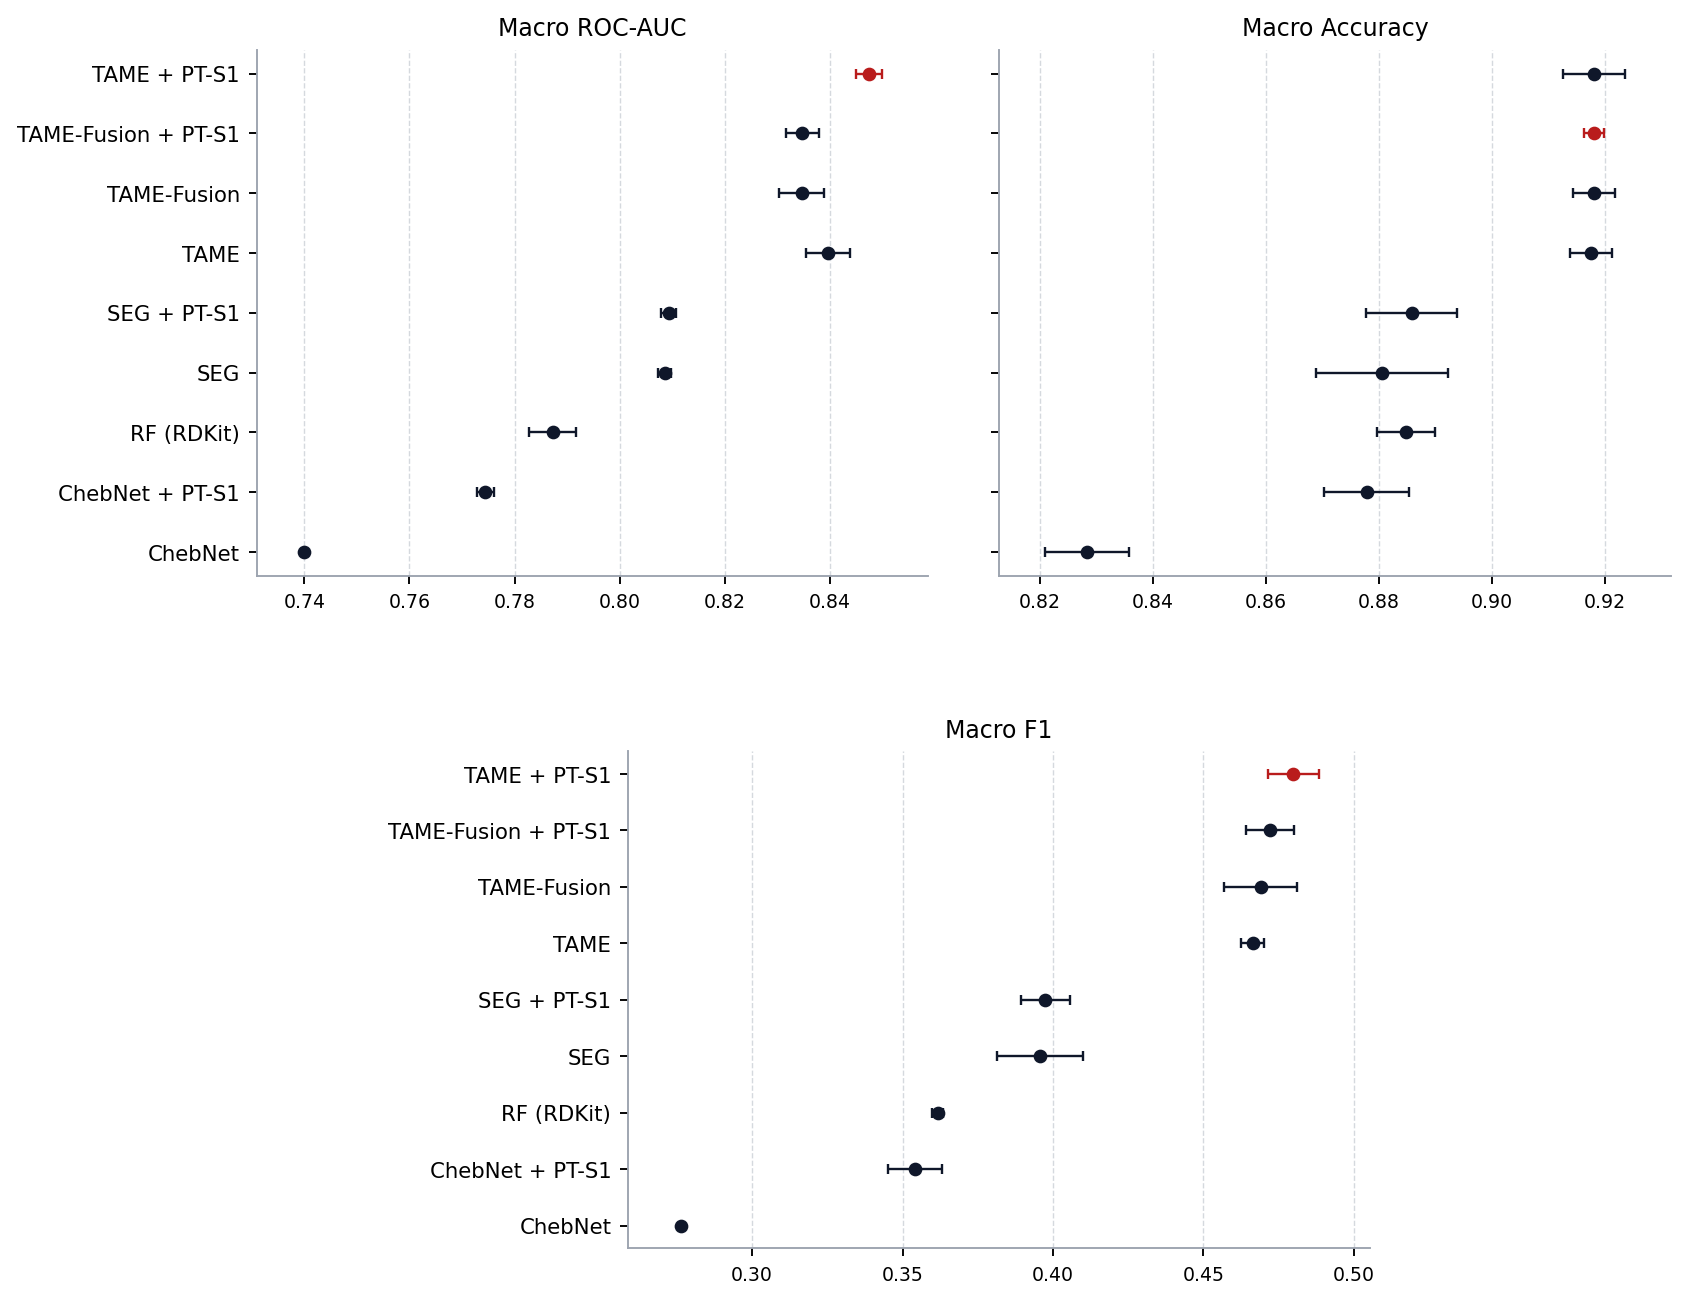

,model,macro_roc_auc_mean,macro_roc_auc_std,macro_accuracy_mean,macro_accuracy_std,macro_f1_mean,macro_f1_std,threshold_mean,n_tasks_eval_mean,n_runs,label
0,TAME_PRETRAINED_STAGE1,0.847455,0.002456,0.917947,0.005484,0.479924,0.008578,0.332222,12.0,3,TAME + PT-S1
1,TAME_FUSION_PRETRAINED_STAGE1,0.834765,0.003154,0.918030,0.001844,0.472136,0.007850,0.291667,12.0,3,TAME-Fusion + PT-S1
2,TAME_FUSION_VANILLA,0.834590,0.004370,0.917990,0.003738,0.469081,0.012167,0.236111,12.0,3,TAME-Fusion
3,TAME_VANILLA,0.839644,0.004178,0.917408,0.003708,0.466378,0.003870,0.298750,12.0,3,TAME
4,SEG_PRETRAINED_STAGE1,0.809293,0.001361,0.885746,0.008060,0.397488,0.008236,0.242500,12.0,3,SEG + PT-S1
5,SEG_VANILLA,0.808593,0.001234,0.880563,0.011688,0.395674,0.014380,0.201667,12.0,3,SEG
6,RF_RDKit_MULTILABEL,0.787212,0.004453,0.884835,0.005109,0.361716,0.001834,0.137778,12.0,3,RF (RDKit)
7,CHEBNET_TASKWISE_PRETRAINED_STAGE1,0.774447,0.001697,0.877830,0.007533,0.354174,0.009001,0.171111,12.0,3,ChebNet + PT-S1
8,CHEBNET_TASKWISE_VANILLA,0.739945,0.000234,0.828422,0.007424,0.276413,0.000709,0.124444,12.0,3,ChebNet


In [2]:
# Reload saved Tox21 benchmark summary and re-plot in a 2-top / 1-centered-bottom layout.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'benchmarking').exists()), here)

results_dir = workspace_root / 'benchmarking' / 'results'
summary_path = results_dir / 'tox21_full_benchmark_3seed_summary.csv'

if not summary_path.exists():
    raise FileNotFoundError(f'Summary file not found: {summary_path}')

summary_plot_df_reload = pd.read_csv(summary_path)

# Classification: higher is better. Use a robust overall rank across all three metrics.
summary_plot_df_reload['rank_auc'] = summary_plot_df_reload['macro_roc_auc_mean'].rank(ascending=False, method='average')
summary_plot_df_reload['rank_acc'] = summary_plot_df_reload['macro_accuracy_mean'].rank(ascending=False, method='average')
summary_plot_df_reload['rank_f1'] = summary_plot_df_reload['macro_f1_mean'].rank(ascending=False, method='average')
summary_plot_df_reload['rank_total'] = (
    summary_plot_df_reload['rank_auc']
    + summary_plot_df_reload['rank_acc']
    + summary_plot_df_reload['rank_f1']
)
summary_plot_df_reload = summary_plot_df_reload.sort_values(['rank_total', 'macro_roc_auc_mean'], ascending=[True, False]).reset_index(drop=True)

label_map_reload = {
    'RF_RDKit_MULTILABEL': 'RF (RDKit)',
    'CHEBNET_TASKWISE_VANILLA': 'ChebNet',
    'CHEBNET_TASKWISE_PRETRAINED_STAGE1': 'ChebNet + PT-S1',
    'SEG_VANILLA': 'SEG',
    'SEG_PRETRAINED_STAGE1': 'SEG + PT-S1',
    'TAME_VANILLA': 'TAME',
    'TAME_PRETRAINED_STAGE1': 'TAME + PT-S1',
    'TAME_FUSION_VANILLA': 'TAME-Fusion',
    'TAME_FUSION_PRETRAINED_STAGE1': 'TAME-Fusion + PT-S1',
}
summary_plot_df_reload['label'] = summary_plot_df_reload['model'].map(label_map_reload).fillna(summary_plot_df_reload['model'])

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 400,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#111111',
    'axes.linewidth': 0.8,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 9,
})

y = np.arange(len(summary_plot_df_reload))
y_labels = summary_plot_df_reload['label'].tolist()

fig = plt.figure(figsize=(10.4, 8.6))
ax_auc = fig.add_axes([0.08, 0.56, 0.38, 0.36])
ax_acc = fig.add_axes([0.50, 0.56, 0.38, 0.36], sharey=ax_auc)
ax_f1 = fig.add_axes([0.29, 0.10, 0.42, 0.34])

axes = [ax_auc, ax_acc, ax_f1]
metrics_reload = [
    ('macro_roc_auc_mean', 'macro_roc_auc_std', 'Macro ROC-AUC'),
    ('macro_accuracy_mean', 'macro_accuracy_std', 'Macro Accuracy'),
    ('macro_f1_mean', 'macro_f1_std', 'Macro F1'),
]

for ax, (m_col, s_col, title) in zip(axes, metrics_reload):
    mu = summary_plot_df_reload[m_col].to_numpy(dtype=np.float32)
    sd = summary_plot_df_reload[s_col].fillna(0.0).to_numpy(dtype=np.float32)

    # Classification metrics: always higher is better.
    best_idx = int(np.argmax(mu))

    for i in range(len(mu)):
        c = '#0f172a' if i != best_idx else '#b91c1c'
        ax.errorbar(
            mu[i], y[i], xerr=sd[i], fmt='o', markersize=4.8,
            color=c, ecolor=c, elinewidth=1.0, capsize=2, capthick=1.0
        )

    xmin = float(np.min(mu - sd))
    xmax = float(np.max(mu + sd))
    pad = 0.08 * (xmax - xmin + 1e-8)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_title(title, pad=6)
    ax.grid(axis='x', color='#d1d5db', linestyle='--', linewidth=0.6, alpha=0.9)
    ax.grid(axis='y', visible=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#9ca3af')
    ax.spines['bottom'].set_color('#9ca3af')

# Invert only once per independent y-axis (avoid double inversion on shared y).
ax_auc.invert_yaxis()
ax_f1.invert_yaxis()

ax_auc.set_yticks(y, labels=y_labels)
ax_acc.tick_params(axis='y', labelleft=False)
ax_f1.set_yticks(y, labels=y_labels)
ax_acc.set_ylim(ax_auc.get_ylim())

plt.show()

summary_plot_df_reload.drop(columns=['rank_auc', 'rank_acc', 'rank_f1', 'rank_total'])